Sample database created successfully.

--- Sales by Product ---
      product  total_qty  revenue
0  Smartphone         18  14400.0
1      Laptop          8   9600.0
2  Smartwatch         25   6250.0
3      Tablet         12   4800.0
4  Headphones         32   4800.0

--- Sales by Month ---
     month  total_qty  revenue
0  2023-01         57  23550.0
1  2023-02         38  16300.0

Total Revenue: $39,850.00
Total Quantity Sold: 95 units


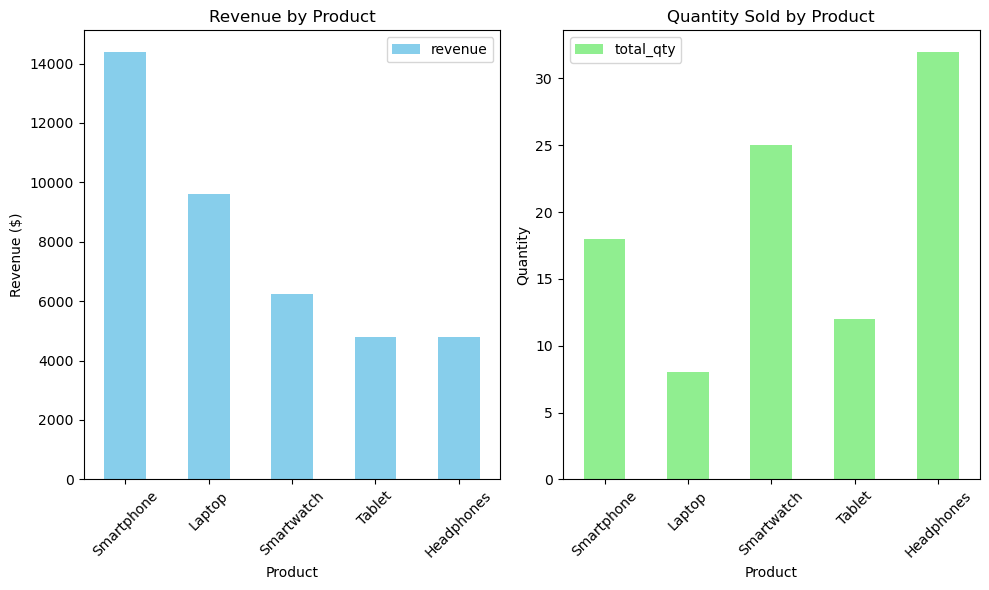

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Create a small SQLite database with sample sales data
def create_sample_database():
    """Create a sample sales database with some test data"""
    conn = sqlite3.connect('sales_data.db')
    cursor = conn.cursor()
    
    # Create sales table
    cursor.execute('''
    CREATE TABLE IF NOT EXISTS sales (
        id INTEGER PRIMARY KEY,
        product TEXT,
        quantity INTEGER,
        price REAL,
        date TEXT
    )
    ''')
    
    # Insert sample data
    sample_data = [
        ('Laptop', 5, 1200.00, '2023-01-15'),
        ('Smartphone', 10, 800.00, '2023-01-17'),
        ('Headphones', 20, 150.00, '2023-01-20'),
        ('Tablet', 7, 400.00, '2023-01-22'),
        ('Smartwatch', 15, 250.00, '2023-01-25'),
        ('Laptop', 3, 1200.00, '2023-02-05'),
        ('Smartphone', 8, 800.00, '2023-02-10'),
        ('Headphones', 12, 150.00, '2023-02-15'),
        ('Tablet', 5, 400.00, '2023-02-20'),
        ('Smartwatch', 10, 250.00, '2023-02-25')
    ]
    
    cursor.executemany('''
    INSERT INTO sales (product, quantity, price, date)
    VALUES (?, ?, ?, ?)
    ''', sample_data)
    
    conn.commit()
    conn.close()
    print("Sample database created successfully.")

# Step 2: Connect to the database and run queries
def analyze_sales_data():
    """Connect to the database and analyze sales data"""
    conn = sqlite3.connect('sales_data.db')
    
    # Query 1: Get total quantity sold and revenue by product
    query1 = """
    SELECT product, 
           SUM(quantity) AS total_qty, 
           SUM(quantity * price) AS revenue 
    FROM sales 
    GROUP BY product
    ORDER BY revenue DESC
    """
    
    # Query 2: Get monthly sales
    query2 = """
    SELECT strftime('%Y-%m', date) AS month, 
           SUM(quantity) AS total_qty, 
           SUM(quantity * price) AS revenue 
    FROM sales 
    GROUP BY month
    ORDER BY month
    """
    
    # Load query results into pandas DataFrames
    df_products = pd.read_sql_query(query1, conn)
    df_months = pd.read_sql_query(query2, conn)
    
    # Display results
    print("\n--- Sales by Product ---")
    print(df_products)
    
    print("\n--- Sales by Month ---")
    print(df_months)
    
    # Calculate total sales
    total_sales = df_products['revenue'].sum()
    total_quantity = df_products['total_qty'].sum()
    print(f"\nTotal Revenue: ${total_sales:,.2f}")
    print(f"Total Quantity Sold: {total_quantity} units")
    
    # Create visualizations
    plt.figure(figsize=(10, 6))
    
    # Product revenue bar chart
    ax1 = plt.subplot(1, 2, 1)
    df_products.plot(kind='bar', x='product', y='revenue', ax=ax1, color='skyblue')
    plt.title('Revenue by Product')
    plt.xlabel('Product')
    plt.ylabel('Revenue ($)')
    plt.xticks(rotation=45)
    
    # Product quantity bar chart
    ax2 = plt.subplot(1, 2, 2)
    df_products.plot(kind='bar', x='product', y='total_qty', ax=ax2, color='lightgreen')
    plt.title('Quantity Sold by Product')
    plt.xlabel('Product')
    plt.ylabel('Quantity')
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.savefig("sales_chart.png")
    plt.show()
    
    conn.close()

if __name__ == "__main__":
    # Create the sample database (comment this out if you already have the database)
    create_sample_database()
    
    # Analyze the sales data
    analyze_sales_data()